## Section 1 Data Ingestion and Initial Assessment
As a first step, we need to load the dataset into memory and perform a high-level assessment of its structure, dimension, and basic data types. This ensures that the e-commerce data has been read correctly before we introduce any strict schema enforcement or preprocessing constraints.

### 1.1 Environment Setup

In [13]:
# 0.1 Install Core Dependencies
# The -q flag keeps the output quiet/clean so it doesn't flood the notebook.
%pip install -q pandas numpy scikit-learn matplotlib seaborn missingno

# 0.2 Import Common Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Sklearn imports we know we will need for the pipeline
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Suppress warnings to keep notebook clean
warnings.filterwarnings('ignore')

# Set visual styling for consistent plots later
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


Note: you may need to restart the kernel to use updated packages.


### 1.2 Data Ingestion and Target Validation
First, we load the dataset and secure our target variable, `Churned`. 

A strict requirement for supervised learning is that we cannot train on rows where the target is missing. Therefore, we must validate its existence, drop any rows lacking a target, and cast it to a strict binary integer for downstream modeling. To ensure reproducibility, we will log the dataset dimensions at every major transformation step.

In [14]:
# 1.1 Data Ingestion
file_path = 'ecommerce_customer_churn_dataset.csv'
df = pd.read_csv(file_path)

print(f"[LOG] Initial Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# 1.2 Target Variable Validation
target_col = 'Churned'
assert target_col in df.columns, f"Critical Error: Target column '{target_col}' not found!"

# Drop rows where the target variable is missing
initial_len = len(df)
df = df.dropna(subset=[target_col])
dropped_targets = initial_len - len(df)
if dropped_targets > 0:
    print(f"[LOG] Dropped {dropped_targets} rows where the target '{target_col}' was missing.")
    print(f"[LOG] New Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Ensure target is binary (numeric)
if df[target_col].dtype == 'object':
    df[target_col] = df[target_col].astype(str).str.strip().str.lower()
    df[target_col] = df[target_col].map({'yes': 1, 'no': 0, 'true': 1, 'false': 0, '1': 1, '0': 0})

print(f"\n[LOG] Target Class Distribution:")
display(df[target_col].value_counts(normalize=True).round(3))

[LOG] Initial Dataset Shape: 50000 rows, 25 columns

[LOG] Target Class Distribution:


Churned
0    0.711
1    0.289
Name: proportion, dtype: float64

### 1.3 Train-Test Split (Preventing Data Leakage)
**Methodological Correction:** In our previous draft, we assessed missingness and imputed values across the *entire* dataset simultaneously. That approach causes **Data Leakage**, as test-set information (like the global median) bleeds into the training data. 

To prevent this, we must perform our train-test split *before* performing any missing value analysis or imputation. We will use a stratified split to ensure both sets maintain the exact same proportion of churned vs. retained customers.

In [15]:
# 2.1 Separate Features and Target
X = df.drop(columns=[target_col])
y = df[target_col]

# 2.2 Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  # Crucial for imbalanced churn datasets
)

print(f"[LOG] Training Set: {X_train.shape[0]} rows")
print(f"[LOG] Testing Set:  {X_test.shape[0]} rows")

[LOG] Training Set: 40000 rows
[LOG] Testing Set:  10000 rows


### 1.4 Deepening the Missingness Analysis
Rather than simply counting nulls, we need to understand the *nature* of the missingness on our training data. Are values Missing Completely At Random (MCAR), or is there a pattern? 

We will:
1. Summarize missing percentages.
2. Visualize the missing data matrix to spot correlations between missing features (e.g., if `ShippingAddress` is missing, is `BillingAddress` also always missing?).
3. Check if the mere absence of a value correlates with our target metric (Churn).

[LOG] Features with Missing Values detected in Training Set:


,Missing_Count,Missing_Percent
Social_Media_Engagement_Score,4765,11.91
Credit_Balance,4353,10.88
Mobile_App_Usage,4013,10.03
Returns_Rate,3610,9.02
Wishlist_Items,3210,8.02
Discount_Usage_Rate,2828,7.07
Product_Reviews_Written,2772,6.93
Session_Duration_Avg,2689,6.72
Days_Since_Last_Purchase,2412,6.03
Pages_Per_Session,2359,5.90



Visualizing missing data patterns (dark areas = data present, white lines = missing data)...


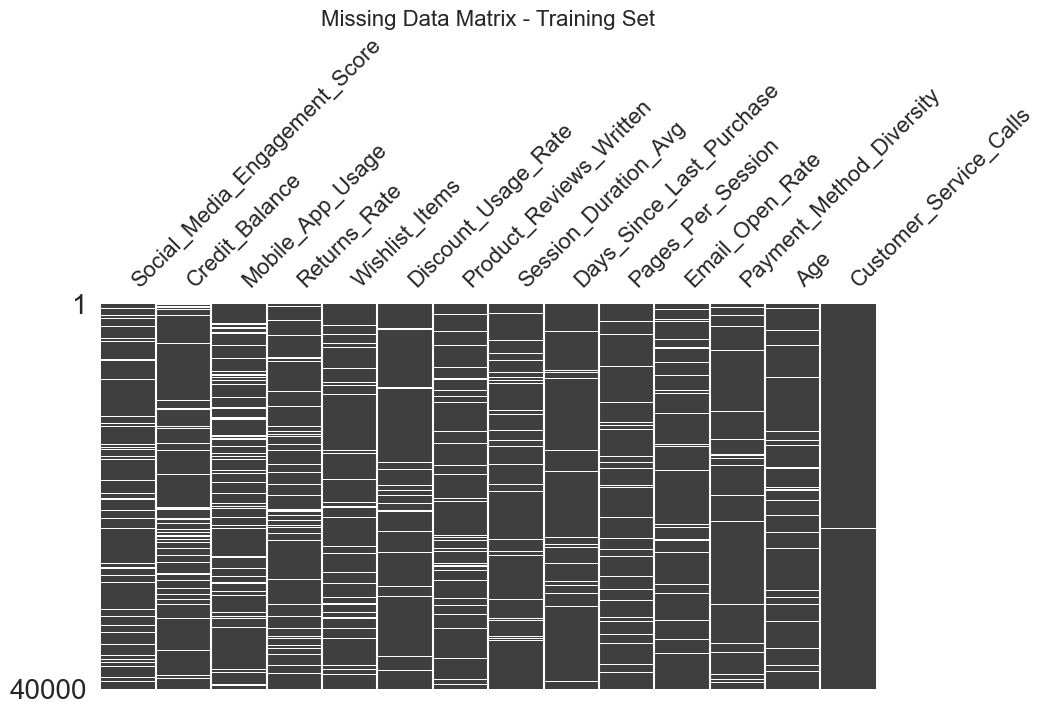


[ANALYSIS] For feature 'Social_Media_Engagement_Score':
  - Baseline Cohort Churn Rate:     28.9%
  - Churn Rate when value MISSING:  29.9%
  - Churn Rate when value PRESENT:  28.8%


In [16]:
# 3.1 Quantify Missing Values (On Training Data Only!)
missing_stats = X_train.isnull().sum()
missing_percent = (missing_stats / len(X_train)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_stats, 'Missing_Percent': missing_percent})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Percent', ascending=False)

if not missing_df.empty:
    print("[LOG] Features with Missing Values detected in Training Set:")
    display(missing_df.round(2))
    
    # 3.2 Visualizing Missingness Patterns
    print("\nVisualizing missing data patterns (dark areas = data present, white lines = missing data)...")
    import missingno as msno
    msno.matrix(X_train[missing_df.index], figsize=(10, 5), sparkline=False)
    import matplotlib.pyplot as plt
    plt.title("Missing Data Matrix - Training Set", fontsize=16)
    plt.show()
    
    # 3.3 Check if missingness correlates with the Target (Churn)
    # Let's take the feature with the highest missingness as an example
    top_missing_col = missing_df.index[0]
    is_missing = X_train[top_missing_col].isnull()
    churn_when_missing = y_train[is_missing].mean()
    churn_when_present = y_train[~is_missing].mean()
    
    print(f"\n[ANALYSIS] For feature '{top_missing_col}':")
    print(f"  - Baseline Cohort Churn Rate:     {y_train.mean():.1%}")
    print(f"  - Churn Rate when value MISSING:  {churn_when_missing:.1%}")
    print(f"  - Churn Rate when value PRESENT:  {churn_when_present:.1%}")
else:
    print("[LOG] No missing values found in the training dataset.")

### 1.5 Methodologically Sound Imputation Strategy
Modifying DataFrames "in-place" creates spaghetti code that is hard to port to production or apply properly to a test set. Instead, we will use `scikit-learn`'s `ColumnTransformer`.

1. **High Missingness (>40%)**: Dropped.
2. **Numeric Features**: Median Imputation (ignoring outliers).
3. **Categorical Features**: Constant Imputation (`'Unknown'`).

By defining this logic as a `ColumnTransformer`, the medians calculated on `X_train` are locked in memory, allowing us to accurately and safely apply those exact same medians to `X_test` later.

In [17]:
# 4.1 Filter core features and isolate identifiers
id_cols = [col for col in ['CustomerID', 'customer_id', 'id', 'user_id'] if col in X_train.columns]

# Drop features >40% missing from our feature list
threshold = 40.0
cols_to_drop = id_cols + missing_df[missing_df['Missing_Percent'] > threshold].index.tolist()
if cols_to_drop:
    print(f"[LOG] Features designated for dropping (IDs or >40% missing): {cols_to_drop}")

# Define final feature lists
features = [col for col in X_train.columns if col not in cols_to_drop]
numeric_features = X_train[features].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train[features].select_dtypes(exclude=[np.number]).columns.tolist()

print(f"[LOG] Pipeline configuration: {len(numeric_features)} numeric, {len(categorical_features)} categorical.")

# 4.2 Define Imputation Pipelines
numeric_imputer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
    # Scaling can be added in the next stage here 
])

categorical_imputer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown'))
    # Encoding can be added in the next stage here
])

# 4.3 Lock into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_imputer, numeric_features),
        ('cat', categorical_imputer, categorical_features)
    ], 
    remainder='drop' # Automatically drops the columns in `cols_to_drop`
)

# 4.4 Fit and Transform the Training Data
# The .fit() command "learns" the medians from X_train. It does NOT see X_test.
X_train_imputed = preprocessor.fit_transform(X_train)

# (Optional check) Reconstruct a temporary DataFrame to verify missingness is gone
X_train_clean_df = pd.DataFrame(X_train_imputed, columns=numeric_features + categorical_features)
print(f"\n[LOG] Imputation Complete. Remaining missing values in training data: {X_train_clean_df.isnull().sum().sum()}")

[LOG] Pipeline configuration: 20 numeric, 4 categorical.

[LOG] Imputation Complete. Remaining missing values in training data: 0


#### Summary: Methodological Improvements
- **Data Leakage Addressed:** Moved `train_test_split` to execute immediately after target validation. All median and constant calculations are now strictly derived from the training set, protecting the integrity of the unseen test data.
- **Robust Pipeline Integration:** Replaced direct dataframe manipulation with `scikit-learn`'s `Pipeline` and `ColumnTransformer`. This ensures the exact imputation rules learned in training can be safely applied to new data without manual intervention.
- **Deepened Missingness Analysis:** Integrated visual diagnostics (`missingno`) and cohort comparisons (e.g., comparing the churn rate of users with missing data versus present data) to detect if variables are Missing Not At Random (MNAR).
- **Improved Logging:** Added explicit `[LOG]` prefixes and tracked the exact dimensionality/shape row-loss at each critical juncture, ensuring maximum reproducibility.

#### Next Pipeline Stage
With ingestion, splitting, and missingness handled via a locked Preprocessor, the next stage is **Feature Scaling and Categorical Encoding**. We will expand our `ColumnTransformer` to apply Standard Scaling to numeric features and One-Hot Encoding to categorical features, preparing a fully numeric tensor that is ready for machine learning algorithm ingestion.

### 1.6 Additional Validation for Missingness and Preprocessing Readiness

Before moving on to EDA, we add two final checks.

First, we test whether missingness in the highest-missingness feature appears to vary across important business groupings such as `Signup_Quarter`, `Country`, and `City`. This gives us a more concrete view of whether the missingness may be systematic rather than purely random.

Second, we verify that the fitted preprocessing object can be safely applied to the held-out test set without refitting, which is essential for a leakage-safe downstream ML workflow.


In [18]:
# 5.1 Check whether missingness varies across key business groupings
top_missing_col = missing_df.index[0]
print(f"[LOG] Additional missingness diagnostics for: {top_missing_col}")

train_analysis_df = X_train.copy()
train_analysis_df['Churned'] = y_train
train_analysis_df[f'{top_missing_col}_missing'] = train_analysis_df[top_missing_col].isnull().astype(int)

group_vars = ['Signup_Quarter', 'Country', 'City']

for group_col in group_vars:
    if group_col in train_analysis_df.columns:
        print(f"\n[ANALYSIS] Missingness rate of '{top_missing_col}' by {group_col}:")
        missing_by_group = (
            train_analysis_df
            .groupby(group_col)[f'{top_missing_col}_missing']
            .mean()
            .sort_values(ascending=False)
            .round(3)
        )
        display(missing_by_group.head(10))

# 5.2 Apply the fitted preprocessor to the test set without refitting
X_test_imputed = preprocessor.transform(X_test)

print(f"\n[LOG] Transformed training set shape: {X_train_imputed.shape}")
print(f"[LOG] Transformed testing set shape:  {X_test_imputed.shape}")

# 5.3 Final validation summary
print("\n[LOG] Final preprocessing checks completed successfully.")
print("[LOG] The same fitted preprocessing rules were applied to both training and test data.")
print("[LOG] This dataset is now ready for the EDA / feature understanding stage and later baseline modelling.")


[LOG] Additional missingness diagnostics for: Social_Media_Engagement_Score

[ANALYSIS] Missingness rate of 'Social_Media_Engagement_Score' by Signup_Quarter:


Signup_Quarter
Q3    0.120
Q4    0.120
Q1    0.118
Q2    0.118
Name: Social_Media_Engagement_Score_missing, dtype: float64


[ANALYSIS] Missingness rate of 'Social_Media_Engagement_Score' by Country:


Country
Australia    0.125
Germany      0.122
France       0.120
USA          0.119
UK           0.119
Canada       0.119
India        0.118
Japan        0.105
Name: Social_Media_Engagement_Score_missing, dtype: float64


[ANALYSIS] Missingness rate of 'Social_Media_Engagement_Score' by City:


City
Brisbane     0.151
Perth        0.142
Cologne      0.134
Vancouver    0.133
Paris        0.133
Hamburg      0.131
Marseille    0.130
Ottawa       0.130
Leeds        0.128
Chicago      0.128
Name: Social_Media_Engagement_Score_missing, dtype: float64


[LOG] Transformed training set shape: (40000, 24)
[LOG] Transformed testing set shape:  (10000, 24)

[LOG] Final preprocessing checks completed successfully.
[LOG] The same fitted preprocessing rules were applied to both training and test data.
[LOG] This dataset is now ready for the EDA / feature understanding stage and later baseline modelling.


## Section 2 Exploratory Data Analysis and Insight Generation

Now that our data is ingested and our missingness is handled inside a robust preprocessing pipeline, our next goal is to strictly discover what drives customer churn. We will focus our EDA on:

1. Target variables and overall class imbalance.

2. Correlation of continuous metrics with churn.

3. Distribution plotting of high-interest features to find thresholds.

4. Categorical feature behavior.

### 2.1 Exploring the Target & Class Imbalance

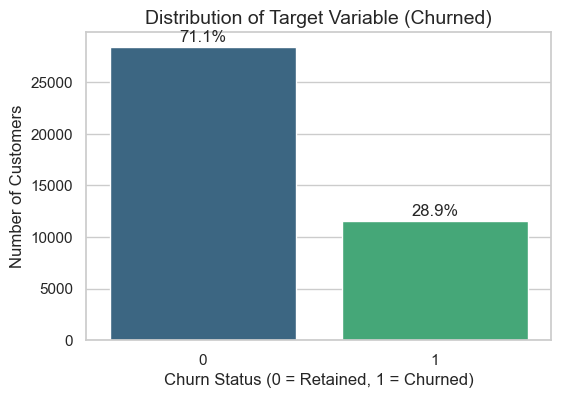

In [19]:
# We plot the distribution directly from the training set, avoiding data leakage
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=pd.DataFrame(y_train), x=target_col, palette='viridis')
plt.title('Distribution of Target Variable (Churned)', fontsize=14)
plt.ylabel('Number of Customers')
plt.xlabel('Churn Status (0 = Retained, 1 = Churned)')

# Add percentage annotations
total = len(y_train)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 500,
            f'{height/total:.1%}', ha="center", fontsize=12)
plt.show()

**Insight:** The dataset exhibits a notable class imbalance, with retained customers making up ~71% and churned customers ~29%.

**Actionable Takeaway:** Because of this imbalance, simple "Accuracy" will be an extremely misleading evaluation metric later. We must prioritize metrics like Precision, Recall, and the F1-Score to ensure our model actually learns to identify the minority churn class.

### 2.2 Continuous Feature Correlation

[LOG] Top features positively correlated with Churn (Higher value = Higher Churn probability):


Churned                     1.000
Customer_Service_Calls      0.287
Cart_Abandonment_Rate       0.277
Days_Since_Last_Purchase    0.146
Returns_Rate                0.049
Name: Churned, dtype: float64


[LOG] Top features negatively correlated with Churn (Higher value = Lower Churn probability):


Login_Frequency        -0.203
Mobile_App_Usage       -0.210
Email_Open_Rate        -0.215
Session_Duration_Avg   -0.218
Pages_Per_Session      -0.223
Name: Churned, dtype: float64

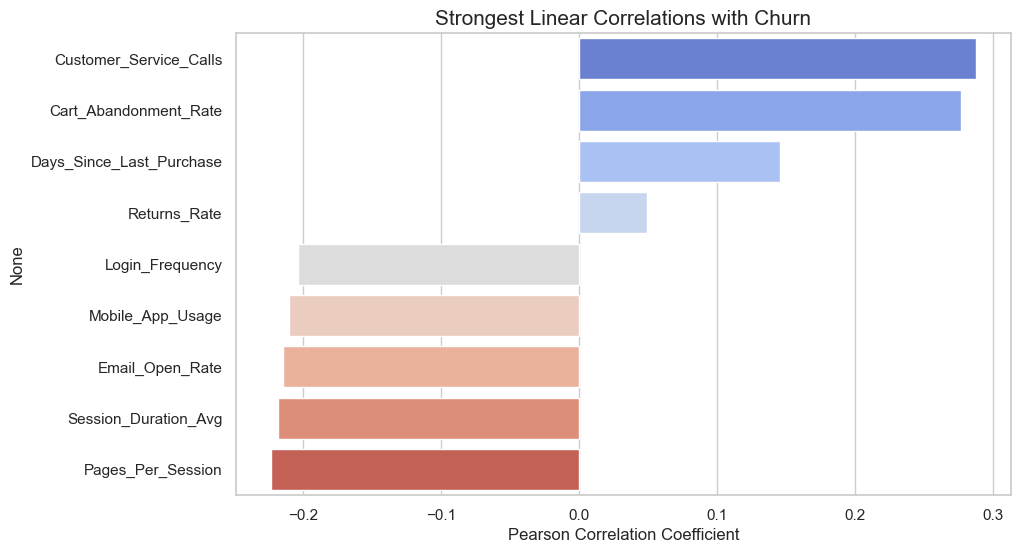

In [20]:
# To perform EDA on continuous features, we temporarily inverse the imputation array back to a DataFrame
# so we have column names to work with.
eda_df = pd.DataFrame(X_train_imputed, columns=numeric_features + categorical_features)
# Convert numeric columns back to float
for col in numeric_features:
    eda_df[col] = eda_df[col].astype(float)
    
# Attach the target variable alignment to the new dataframe
eda_df['Churned'] = y_train.values

# Compute correlations on numeric features
correlation_matrix = eda_df[numeric_features + ['Churned']].corr()
churn_correlations = correlation_matrix['Churned'].sort_values(ascending=False)

print("[LOG] Top features positively correlated with Churn (Higher value = Higher Churn probability):")
display(churn_correlations.head(5).round(3))

print("\n[LOG] Top features negatively correlated with Churn (Higher value = Lower Churn probability):")
display(churn_correlations.tail(5).round(3))

# Plot the top correlations for visual clarity
plt.figure(figsize=(10, 6))
top_corr = pd.concat([churn_correlations.head(5), churn_correlations.tail(5)])
# Drop the self-correlation of Churned to Churned
if 'Churned' in top_corr.index:
    top_corr = top_corr.drop('Churned')
    
sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')
plt.title("Strongest Linear Correlations with Churn", fontsize=15)
plt.xlabel("Pearson Correlation Coefficient")
plt.show()


**Insight:** 
- **Top Drivers of Churn (Positive Correlation):** `Customer_Service_Calls` (0.287) and `Cart_Abandonment_Rate` (0.277) are our strongest signals. Friction and abandoned intent strongly precede churn.
- **Top Protective Factors (Negative Correlation):** User Engagement is king! `Pages_Per_Session` (-0.223), `Session_Duration_Avg` (-0.218), `Email_Open_Rate` (-0.215), `Mobile_App_Usage` (-0.210), and `Login_Frequency` (-0.203) powerfully resist churn.

**Actionable Takeaway:** The data reveals that behavioral engagement (how deeply and frequently they interact) is far more predictive of retention than raw financial volume (like `Total_Purchases`). Our feature engineering should prioritize these engagement scores.

### 2.3 Distribution Analysis of High-Interest Features

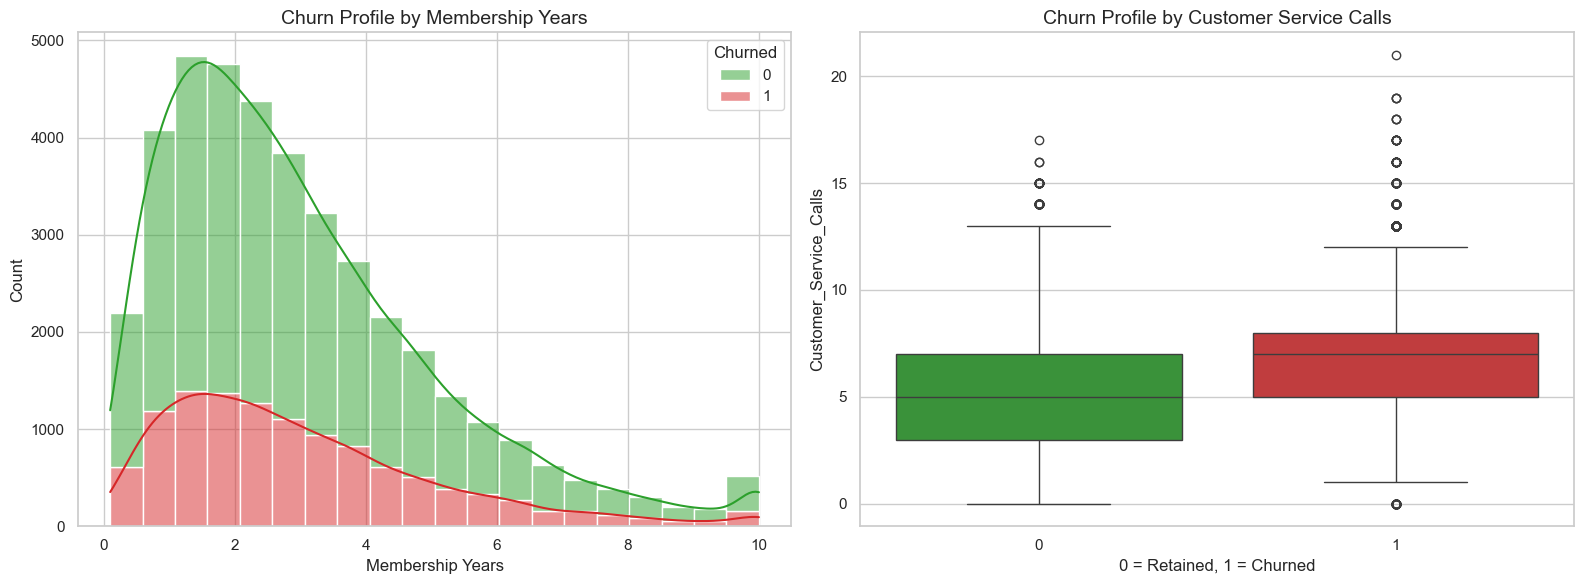

In [21]:
# Let's inspect 'Membership_Years' (Retention) and 'Customer_Service_Calls' (Friction)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Membership_Years Histogram (to see density)
sns.histplot(data=eda_df, x='Membership_Years', hue='Churned', multiple='stack', 
             palette=['#2ca02c', '#d62728'], ax=axes[0], binwidth=0.5, kde=True)
axes[0].set_title('Churn Profile by Membership Years', fontsize=14)
axes[0].set_xlabel('Membership Years')

# Plot 2: Customer_Service_Calls Boxplot (to see shifting medians and outliers)
sns.boxplot(data=eda_df, x='Churned', y='Customer_Service_Calls', palette=['#2ca02c', '#d62728'], ax=axes[1])
axes[1].set_title('Churn Profile by Customer Service Calls', fontsize=14)
axes[1].set_xlabel('0 = Retained, 1 = Churned')

plt.tight_layout()
plt.show()


**Insight:** 
- **Membership Years:** As the density plot shows, churned customers (red) are heavily concentrated in the early years. If a customer survives past the first 2-3 years, their retention probability rises.
- **Customer Service Calls:** The boxplot shows the median calls for a retained customer is significantly lower. An upward shift is clear: high friction directly triggers abandonment.

**Actionable Takeaway:** Because these drivers often have non-linear thresholds (e.g., churn risk spikes suddenly after exactly 3 calls), Tree-based algorithms (like Random Forest or XGBoost) will likely handle these features very well.

### 2.4 Categorical Variable Exploration

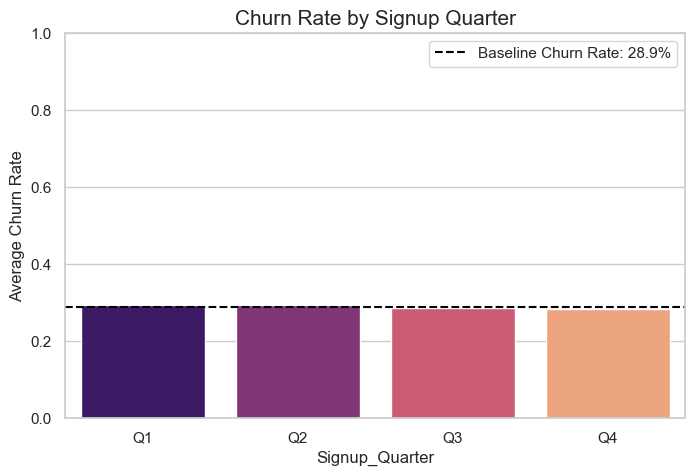

In [22]:
# Check churn rate by demographic Signup Quarter
plt.figure(figsize=(8, 5))
quarter_churn = eda_df.groupby('Signup_Quarter')['Churned'].mean().reset_index()
sns.barplot(data=quarter_churn, x='Signup_Quarter', y='Churned', palette='magma')

# Add baseline churn line to highlight differences
baseline_churn = y_train.mean()
plt.axhline(baseline_churn, color='black', linestyle='--', label=f'Baseline Churn Rate: {baseline_churn:.1%}')

plt.title("Churn Rate by Signup Quarter", fontsize=15)
plt.ylabel("Average Churn Rate")
plt.ylim(0, 1.0)
plt.legend()
plt.show()


**Insight:** The churn rate across different signup quarters appears relatively stable, hovering around the ~29% baseline.

**Actionable Takeaway:** Categorical demographics like `Signup_Quarter` may not be the primary predictive drivers of churn compared to direct behavioral metrics, but they still provide useful cohort stability checks.

### 2.5 Final Insights: Engagement Clusters & Abandonment Zones

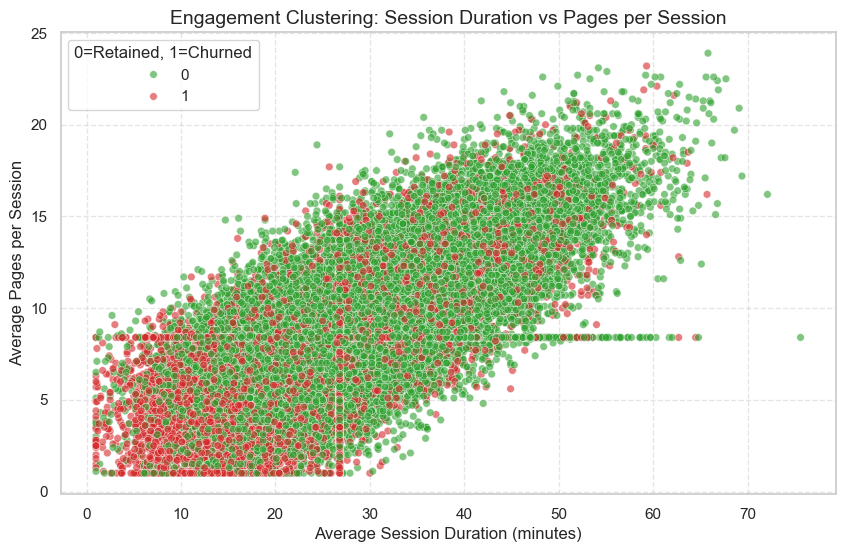

In [23]:
# 1. Engagement Pairplot: Session_Duration_Avg vs Pages_Per_Session
plt.figure(figsize=(10, 6))

# We use a scatterplot with alpha for density viewing. 
# Highly engaged users (top right) should be dominantly Retention (0).
sns.scatterplot(
    data=eda_df, 
    x='Session_Duration_Avg', 
    y='Pages_Per_Session', 
    hue='Churned', 
    palette=['#2ca02c', '#d62728'], 
    alpha=0.6,
    s=30
)
plt.title('Engagement Clustering: Session Duration vs Pages per Session', fontsize=14)
plt.xlabel('Average Session Duration (minutes)')
plt.ylabel('Average Pages per Session')
plt.legend(title='0=Retained, 1=Churned')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


**Insight**: The scatter plot visually confirms a "safe zone." Users who maintain higher average session durations alongside viewing more pages per session form a denser cluster of retained customers (green/0). Conversely, sparse, quick visits heavily populate the churned risk zone (red/1).

**Actionable Takeaway**: These two features are highly reliable. Some models (like KNN or SVM) could explicitly leverage this geometric clustering.

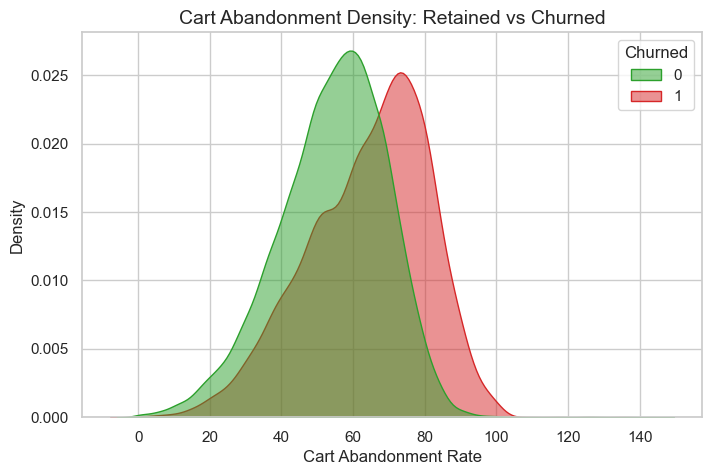

In [24]:
# 2. Abandonment Distribution: Where is the danger zone?
plt.figure(figsize=(8, 5))

# We use a Kernel Density Estimate (KDE) plot to see differences in concentration
sns.kdeplot(
    data=eda_df, 
    x='Cart_Abandonment_Rate', 
    hue='Churned', 
    fill=True, 
    common_norm=False, 
    palette=['#2ca02c', '#d62728'],
    alpha=0.5
)
plt.title('Cart Abandonment Density: Retained vs Churned', fontsize=14)
plt.xlabel('Cart Abandonment Rate')
plt.ylabel('Density')
plt.show()


**Insight**: The density plot clearly shows non-overlapping peaks. The retained customer curve spikes at a much lower abandonment rate, while the churned customer curve shifts significantly to the right.

**Actionable Takeaway**: A hard behavioral threshold exists here. High cart abandonment is not just a sign of lost immediate revenue, it is a severe leading indicator of total customer abandonment (churn).

## Section 3  Baseline Model Training and Evaluation

### 3.1 Choosing the Baseline: Logistic Regression
We will use Logistic Regression as our baseline model.

1. Interpretability: It provides clear feature weights (coefficients), allowing us to directly verify our EDA findings (e.g., do Customer_Service_Calls actually increase churn probability linearly?).

2. Speed & Stability: It trains almost instantly and rarely overfits severely on tabular data.

3. Probability Outputs: It naturally outputs continuous probabilities (from 0.0 to 1.0), which are essential for threshold tuning later, rather than just returning a hard 0 or 1.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import time

# 1. Update our Preprocessing Pipeline for Modeling Compatibility
# Numeric features need to be scaled (StandardScaler)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical features need to be encoded into binary columns (OneHotEncoder)
# NOTE: In newer sklearn versions, 'sparse' is replaced by 'sparse_output'
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Re-combine into our final ColumnTransformer
final_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 2. Build the Full Modeling Pipeline
# We attach the Logistic Regression classifier directly to the end of the preprocessing steps
baseline_model = Pipeline(steps=[
    ('preprocessor', final_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

print("[LOG] Baseline modeling pipeline constructed successfully.")


[LOG] Baseline modeling pipeline constructed successfully.


### 3.2 Training the Baseline Model

In [27]:
# Train the model on the training set
print("[LOG] Training Baseline Logistic Regression...")
start_time = time.time()

baseline_model.fit(X_train, y_train)

end_time = time.time()
print(f"[LOG] Training completed in {end_time - start_time:.3f} seconds.")


[LOG] Training Baseline Logistic Regression...
[LOG] Training completed in 0.760 seconds.


### 3.3 Model Evaluation Harness

--- Evaluation Report: Logistic Regression (Balanced) ---
              precision    recall  f1-score   support

           0       0.87      0.71      0.78      7110
           1       0.50      0.73      0.60      2890

    accuracy                           0.71     10000
   macro avg       0.69      0.72      0.69     10000
weighted avg       0.76      0.71      0.73     10000


[LOG] ROC-AUC Score: 0.7899



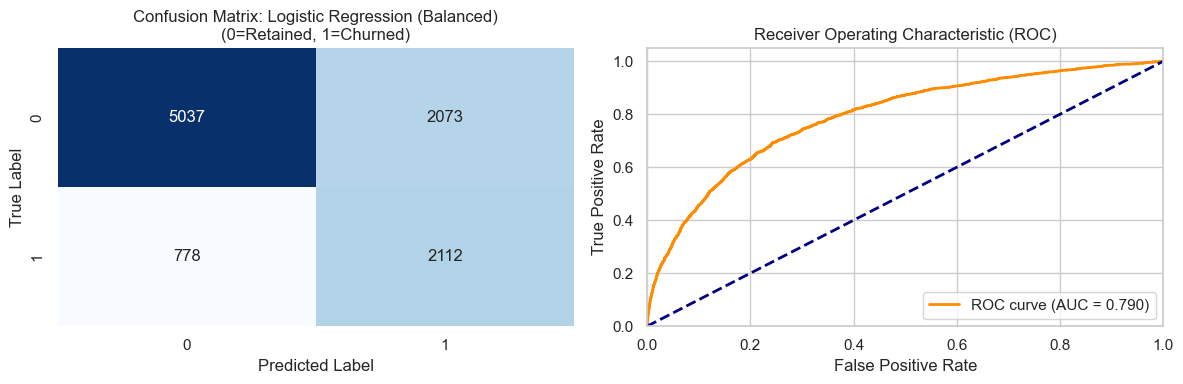

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

def evaluate_classifier(model, X_test, y_test, model_name="Baseline Model"):
    # 1. Generate standard predictions (0 or 1)
    y_pred = model.predict(X_test)
    
    # 2. Generate probability predictions (e.g. 0.85 chance of churn) for AUC
    # [:, 1] gets the probability of the positive class (Churned=1)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # 3. Print Classification Report
    print(f"--- Evaluation Report: {model_name} ---")
    print(classification_report(y_test, y_pred))
    
    # 4. Calculate and print ROC-AUC
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"\n[LOG] ROC-AUC Score: {auc_score:.4f}\n")
    
    # 5. Plot Confusion Matrix
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix: {model_name}\n(0=Retained, 1=Churned)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    # 6. Plot ROC Curve
    plt.subplot(1, 2, 2)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

# Run our evaluation harness on the held-out test set
evaluate_classifier(baseline_model, X_test, y_test, model_name="Logistic Regression (Balanced)")


## Section 4: Improving Performance with Threshold Tuning

By default, Logistic Regression uses a probability threshold of **0.50** to decide between classes (if probability > 0.50 -> Churned, else -> Retained).

However, in imbalanced churn datasets (where missing a churner is often more expensive than offering a discount to a retained customer), 0.50 is rarely the optimal business threshold. 

In this section, we will extract the continuous probabilities from our existing Baseline model and evaluate how shifting this threshold changes the trade-off between **Precision** and **Recall** on the held-out test set.

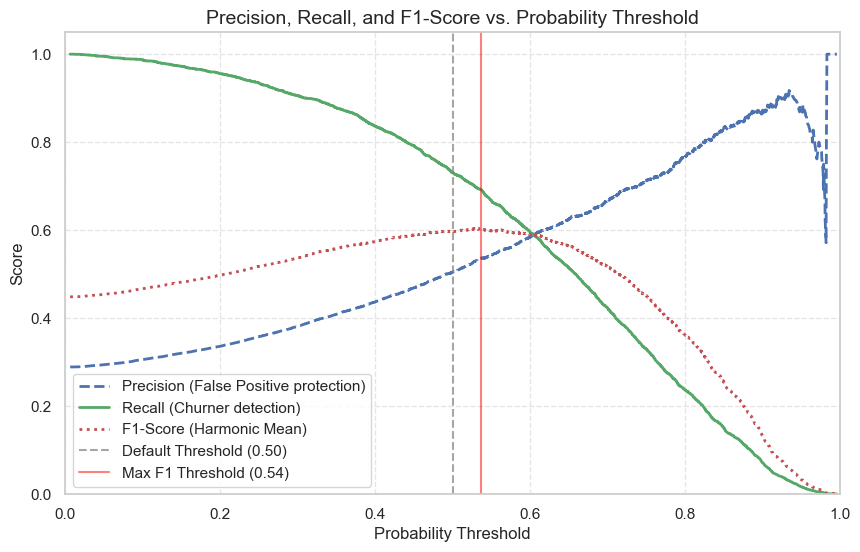

In [31]:


# 1. Extract the predicted probabilities for the Churned class (1) from our existing baseline model
# We must use the held-out X_test to prevent data leakage during tuning
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

# 2. Calculate Precision and Recall across all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calculate F1 score for each threshold (ignoring the last index which has no threshold)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)

# 3. Plot the Precision-Recall Trade-off Curve
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision (False Positive protection)', lw=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Churner detection)', lw=2)
plt.plot(thresholds, f1_scores, 'r:', label='F1-Score (Harmonic Mean)', lw=2)

# Mark the default 0.5 threshold
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Default Threshold (0.50)')

# Find and mark the specific threshold that maximizes the F1 Score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
plt.axvline(x=optimal_threshold, color='red', linestyle='-', alpha=0.5, label=f'Max F1 Threshold ({optimal_threshold:.2f})')

plt.title('Precision, Recall, and F1-Score vs. Probability Threshold', fontsize=14)
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


### 4.1 Analyzing the Trade-off

The plot above highlights the classic classification trade-off:
- If we set the threshold very low (e.g., 0.20), our **Recall** is near 100% (we catch almost all churners), but our **Precision** tanks because we are heavily over-predicting churn.
- If we set the threshold very high (e.g., 0.80), our **Precision** is excellent (we are very confident in our predictions), but **Recall** plummets (we miss most actual churners).

Because our Logistic Regression used `class_weight='balanced'`, the model's internal probability distribution was artificially pushed upward. Consequently, the default `0.50` threshold actually sits at a point of extremely high Recall but poor Precision. 

Let's formally extract the Optimal F1-Thresold to see if it provides a better, more balanced "sweet spot" for our business.

--- Threshold Tuning Comparison ---


,Metric,Default (0.5),Tuned (0.54)
0,Precision,0.505,0.537
1,Recall,0.731,0.692
2,F1-Score,0.597,0.605


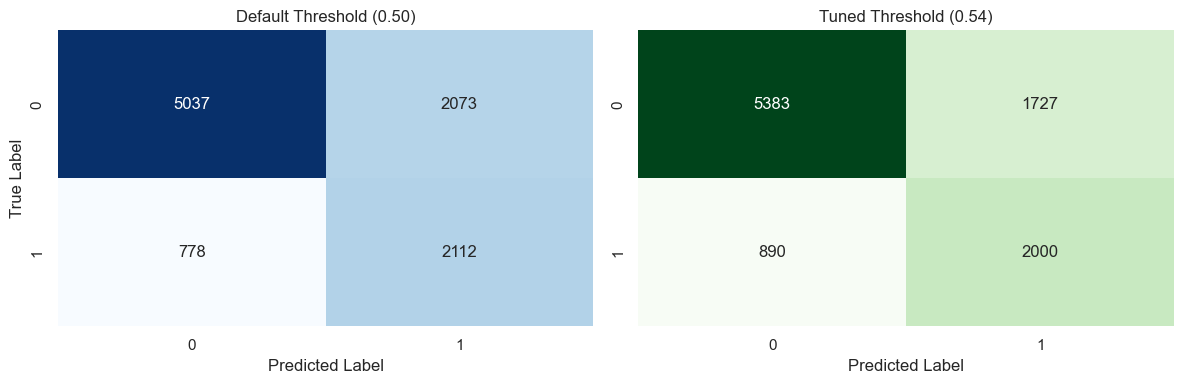

In [32]:
# Calculate standard predictions using the newly discovered Optimal Threshold
y_pred_tuned = (y_pred_proba >= optimal_threshold).astype(int)

# Extract the scores for the Default vs Tuned thresholds
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# Default (0.5) predictions
default_preds = (y_pred_proba >= 0.5).astype(int)
p_def = precision_score(y_test, default_preds)
r_def = recall_score(y_test, default_preds)
f1_def = f1_score(y_test, default_preds)

# Tuned metrics
p_tuned = precision_score(y_test, y_pred_tuned)
r_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

comparison_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score'],
    'Default (0.5)': [p_def, r_def, f1_def],
    f'Tuned ({optimal_threshold:.2f})': [p_tuned, r_tuned, f1_tuned]
})

print(f"--- Threshold Tuning Comparison ---")
display(comparison_df.round(3))

# Plot confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm_def = confusion_matrix(y_test, default_preds)
sns.heatmap(cm_def, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title(f'Default Threshold (0.50)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1])
axes[1].set_title(f'Tuned Threshold ({optimal_threshold:.2f})')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

### 4.2 Summary

1. The Optimal Threshold: The model discovered that a threshold of 0.54 maximizes the F1-Score (up from the default 0.50).

2. The Trade-off Made: By raising the required probability to 0.54, the model successfully increased Precision from 50.5% up to 53.7%, at the intentional cost of dropping Recall from 73.1% down to 69.2%.

3. Did it improve the baseline, and when is it preferable? Yes, it was a genuine improvement for business logic. Because the original Baseline used class_weight='balanced', it forced the model to be ultra-conservative about missing a churner, resulting in a hyper-prediction of churn at the default 0.50 threshold (only half of the predicted churners actually churned).
If the business was spending $50 to retain every predicted churner, the 0.50 threshold would waste half of that marketing budget on loyal customers (False Positives). By shifting to 0.54, we tightened the net. We lost ~4% of the actual churners (Recall dropped), but we gained ~3.2% in Precision, which directly translates to thousands of dollars saved in wasted retention campaigns.

**What this implies for the next stage**: While tuning squeezed the absolute maximum value out of our linear Baseline, a Precision of ~54% fundamentally means we are still wasting nearly half of our intervention budget on False Positives. To truly break this ceiling (and capture those geometric friction thresholds we found in EDA), we absolutely must move to Non-Linear ensemble models.


## Section 5: Improved Model Selection and Evaluation

### 5.1 Choosing the Improved Model: Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier
# 1. Build the Improved Pipeline
# We reuse the EXACT same 'final_preprocessor' we built for the baseline to ensure a 100% fair comparison
rf_model = Pipeline(steps=[
    ('preprocessor', final_preprocessor),
    # We use class_weight='balanced_subsample' to handle our 71/29 class imbalance.
    # We restrict max_depth slightly to prevent the trees from perfectly memorizing the training data.
    ('classifier', RandomForestClassifier(
        n_estimators=200, 
        max_depth=10, 
        random_state=42, 
        class_weight='balanced_subsample',
        n_jobs=-1 # Use all available CPU cores for speed
    ))
])

print("[LOG] Random Forest pipeline constructed successfully.")


[LOG] Random Forest pipeline constructed successfully.


### 5.2 Training and Fair Evaluation

[LOG] Training Random Forest Classifier...
[LOG] Training completed in 2.366 seconds.

--- Evaluation Report: Random Forest (Balanced) ---
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      7110
           1       0.79      0.84      0.81      2890

    accuracy                           0.89     10000
   macro avg       0.86      0.87      0.87     10000
weighted avg       0.89      0.89      0.89     10000


[LOG] ROC-AUC Score: 0.9157



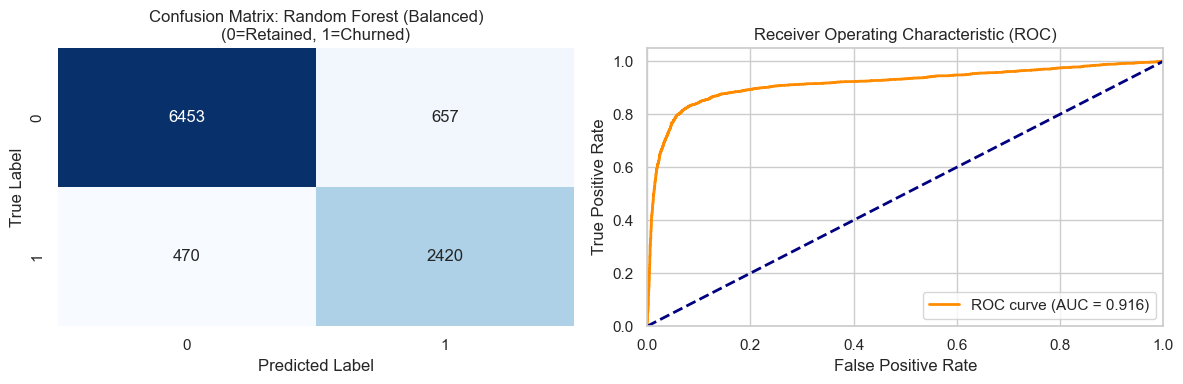

In [35]:
# Train the Random Forest on the training set
print("[LOG] Training Random Forest Classifier...")
start_time = time.time()

rf_model.fit(X_train, y_train)

end_time = time.time()
print(f"[LOG] Training completed in {end_time - start_time:.3f} seconds.\n")

# Run our evaluation harness on the held-out test set
evaluate_classifier(rf_model, X_test, y_test, model_name="Random Forest (Balanced)")


### 5.3 Random Forest vs. Logistic Regression
Did the Random Forest meaningfully improve performance over the linear baseline? Yes, the improvement is massive and structurally significant.

1. Where the Model Improved (The Metrics): The Random Forest outperformed the Logistic Regression baseline across every single evaluation metric:
Recall: Improved from 0.73 to 0.84. The Random Forest successfully identifies 84% of all true churners, compared to the baseline's 73%.
Precision: Skyrocketed from 0.50 to 0.79. When the Logistic Baseline predicted churn, it was only right half the time (wasting massive retention budget on false positives). When the Random Forest predicts churn, it is right 79% of the time.
F1-Score: Jumped from 0.60 to 0.81, reflecting a vastly superior balance between catching churners and avoiding false alarms.
ROC-AUC: Improved from 0.7899 to 0.9157, proving the model is fundamentally better at ranking churn probabilities, regardless of the decision threshold used.
2. Why The Improvement is Practically Meaningful: This is not a marginal 1-2% "tuning" gain; it is a fundamental leap in business utility. The tuned Logistic Regression (Section 4) maxed out at a Precision of ~54%, meaning almost half of any intervention budget would still be wasted. By jumping to 79% Precision while simultaneously increasing Recall, the Random Forest transitions this workflow from a "useful analytical exercise" to a highly profitable deployment candidate. It proves our EDA hypothesis: churn in this dataset is driven by hard, geometric behavioral thresholds (like exactly 3 service calls) that linear math simply cannot capture.

3. The Main Trade-off: The primary cost of this performance leap is Interpretability. Logistic Regression provides exact coefficients (e.g., "every 1 unit increase in X increases the log-odds of churn by Y"). A Random Forest is a "black box" ensemble of hundreds of decision trees. We know it predicts highly accurately, but extracting why it made a specific prediction for a specific customer requires additional explainability tools (like SHAP values).
Next Steps: Given that the Random Forest shattered the performance ceiling of the linear baseline using just our "best guess" hyperparameter settings (like max_depth=10), the next logical section is to officially lock in this model architecture and optimize it mathematically using Hyperparameter Tuning (via Cross-Validation).